<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/CNN_MNIST_(Fashion).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST Clothing Classification

The Fashion MNIST dataset is meant to be a (slightly more challenging) drop-in replacement for the (less challenging) MNIST dataset.

Similar to the MNIST digit dataset, the Fashion MNIST dataset includes:

60,000 training examples

10,000 testing examples

10 classes

28×28 grayscale/single channel images

It is a dataset comprised of 60,000 small square 28×28 pixel grayscale images of items of 10 types of clothing, such as shoes, t-shirts, dresses, and more. The mapping of all 0-9 integers to class labels is listed below.

0: T-shirt/top

1: Trouser

2: Pullover

3: Dress

4: Coat

5: Sandal

6: Shirt

7: Sneaker

8: Bag

9: Ankle boot

It is a more challenging classification problem than MNIST and top results are achieved by deep learning convolutional neural networks with a classification accuracy of about 90% to 95% on the hold out test dataset.



# Step-1: Loading libraries



In [ ]:


# CNN using tf.Keras - MIST Fashion Dataset

import numpy as np
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
# Importing both TensorFlow and its high level API - Keras.
import tensorflow as tf
from tensorflow import keras
# Setting the random seeds for repeatability
tf.random.set_seed(1)
np.random.seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv2D, BatchNormalization,MaxPooling2D, Flatten
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.optimizers import RMSprop



## Step-2 Loading dataset

In [ ]:
# Load the dataset from sklearn
fashionDB = keras.datasets.fashion_mnist

# Step-3 Data Preprocessing



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of X_train:  (60000, 28, 28)
Shape of X_test:  (10000, 28, 28)


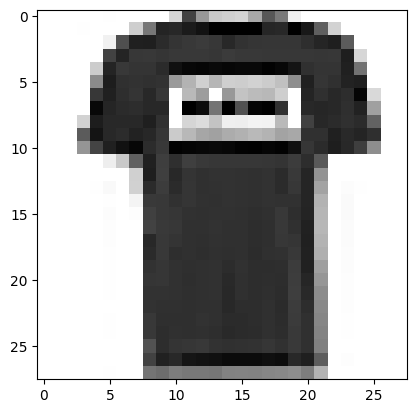

In [ ]:
# Setting the random seeds for repeatability
tf.random.set_seed( 42 )
(X_train, y_train),(X_test, y_test) = fashionDB.load_data()
print("Shape of X_train: ", X_train.shape)
# Shape of X_train:  (60000, 28, 28)
print("Shape of X_test: ", X_test.shape)
# Shape of X_test:  (10000, 28, 28)
# We can view the dataset with matplotlib
plt.imshow(X_train[1], cmap='binary')
plt.show()


## Plotting few images


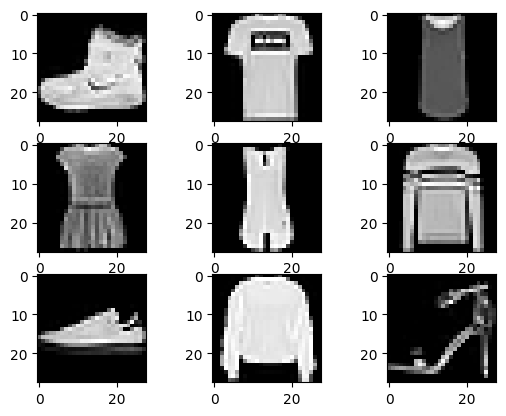

In [ ]:
# plot first few images
for i in range(9):
	# define subplot
	plt.subplot(330 + 1 + i)
	# plot raw pixel data
	plt.imshow(X_train[i], cmap='gray')
# show the figure
plt.show()

# Step-4  Feature Scaling- for Convolutional Neural Network

In [ ]:
X_train = X_train.reshape((60000, 28, 28, 1))
# divided with 255 to bring down the range to 0 to 1.
X_train = X_train.astype('float32')/255
# Similar operations are done to 10000 testing images.
# Flattening 2D image to 1D representation.
X_test = X_test.reshape((10000, 28, 28, 1))
# Scale pixel values to range 0 to 1.
X_test = X_test.astype('float32')/255


#Step 5 CNN Architecture with Convolutional and Deep layers

In [ ]:
X_train.shape[1:]

(28, 28, 1)

In [ ]:
model = Sequential()

# CNN Feature Extraction
model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
# Removed the MaxPooling2D layer here to prevent the input from becoming too small

model.add(Conv2D(256, (3,3), activation='relu'))

# Here begins the fully connected part (DNN) of ConvNet
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 1, 1, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497,194 (1.90 MB)

 Trainable params: 497,194 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

# Step-6 Model Compiling & Training

In [ ]:
# Compile the network model with relevant configurations.
# loss, optimizer and metrics are three important configurations.

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
#optimizer=RMSprop() also can be used


### Model Visualization


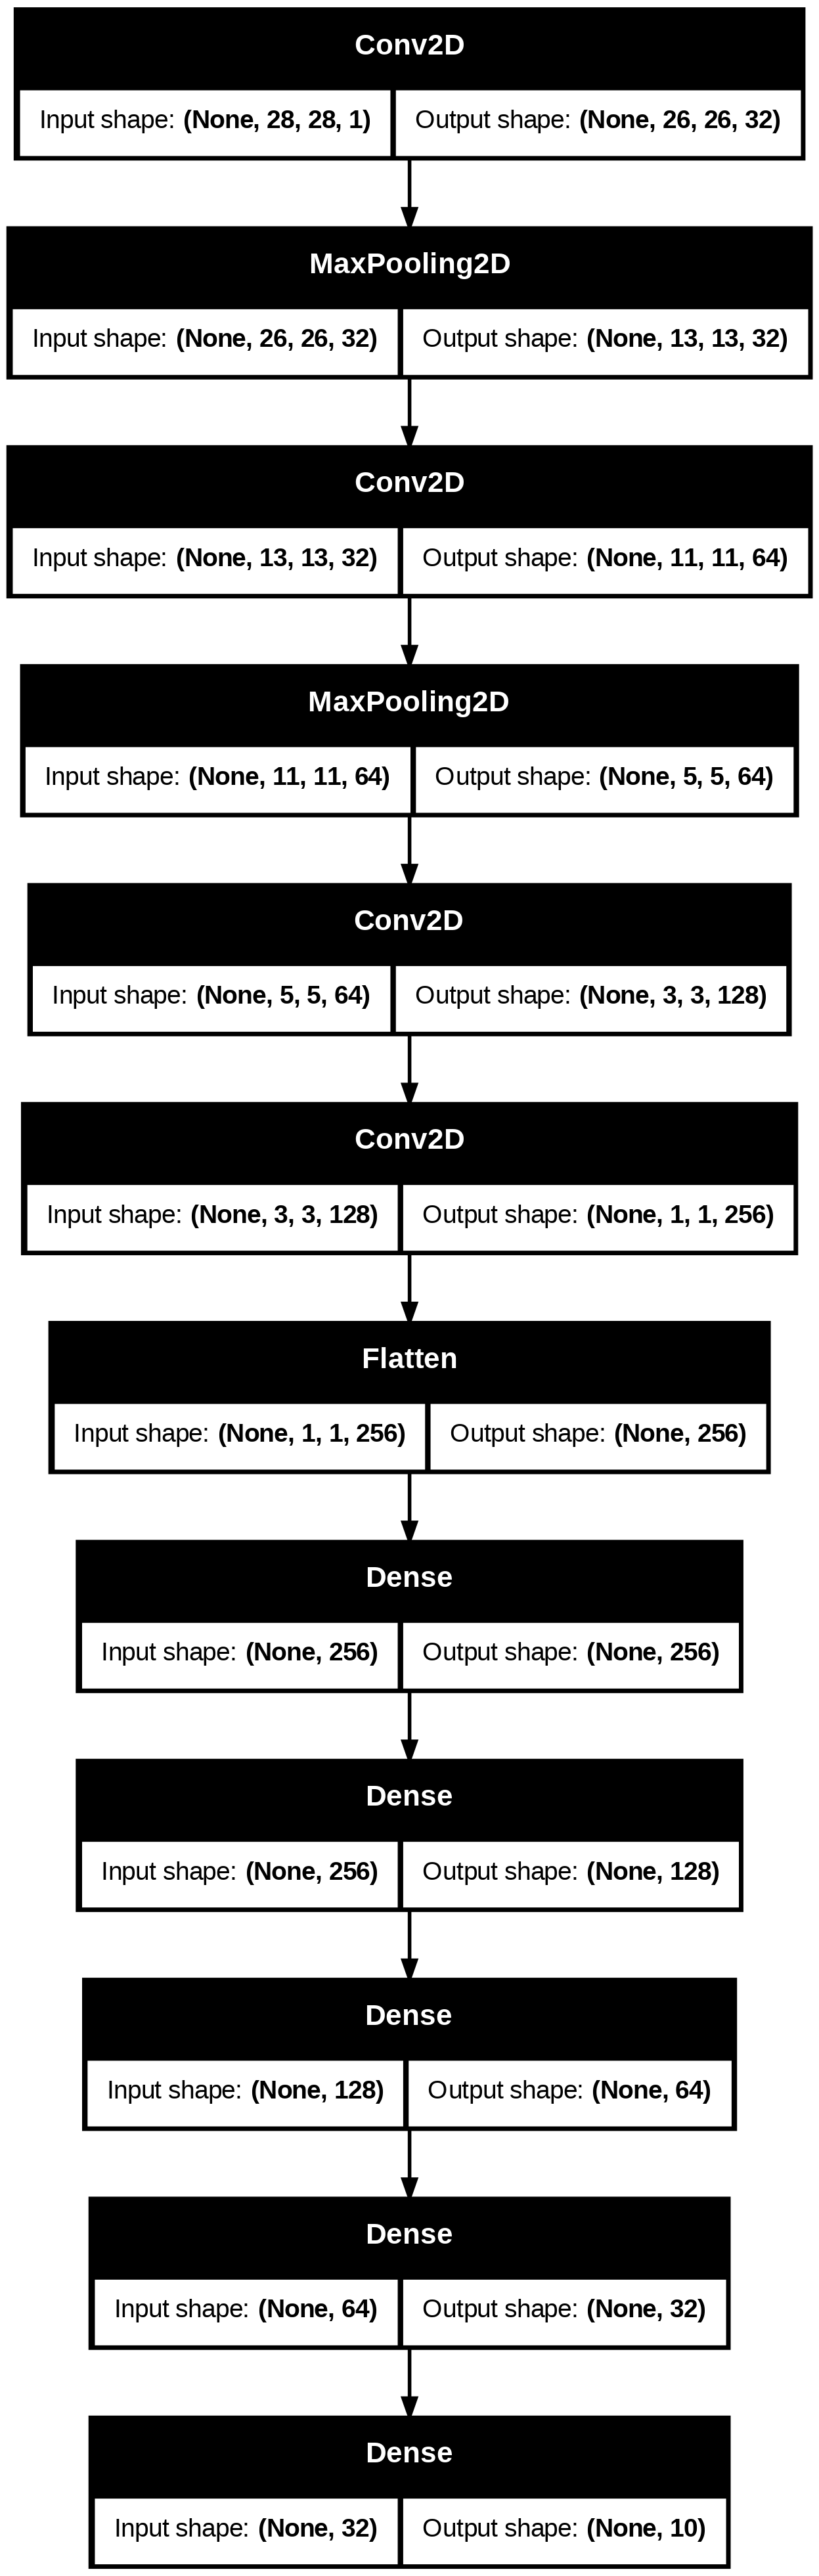

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png',show_shapes=True, show_layer_names=False)

## Target Label encoding

In [ ]:
# convert class vectors to binary class matrices
num_classes=10
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)
# initialize the label names
labelNames = ["top", "trouser", "pullover", "dress", "coat",
	"sandal", "shirt", "sneaker", "bag", "ankle boot"]


In [ ]:
y_train.shape

(60000, 10)

## Model Training

In [ ]:
history = model.fit(x=X_train, y=y_train, validation_split=0.1, epochs=10,
batch_size=16)

Epoch 1/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.7976 - loss: 0.5427 - val_accuracy: 0.8635 - val_loss: 0.3640
Epoch 2/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8772 - loss: 0.3393 - val_accuracy: 0.8712 - val_loss: 0.3493
Epoch 3/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8964 - loss: 0.2862 - val_accuracy: 0.8825 - val_loss: 0.3179
Epoch 4/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9084 - loss: 0.2544 - val_accuracy: 0.8808 - val_loss: 0.3520
Epoch 5/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9169 - loss: 0.2305 - val_accuracy: 0.8840 - val_loss: 0.3501
Epoch 6/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9260 - loss: 0.2072 - val_accuracy: 0.8897 - val_loss: 0.3404
Epoch 7/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9302 - loss: 0.1900 - val_accuracy: 0.8888 - val_loss: 0.3730
Epoch 8/10
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9352 - loss: 0

In [ ]:
# percentage of over-fitting calculation
(0.9425-0.9078)/0.9425*100

3.6816976127320906

## Observation:
 Here the percentage of over-fitting is less than 5%.Also both accuracy are above 90%. So we can accept this difference in accuray during training and validation.

## Displaying the learning of the network

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
plt.savefig("plot.png")

#Step-7  Model Evaluation

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

#Step-8 Confusion Matrix





In [ ]:
y_prob = model.predict(X_test)
from sklearn.metrics import confusion_matrix
y_pred=np.argmax(y_prob, axis=1)
#print(y_pred)
#y_pred.shape
y_temp=y_test>0.5
y_temp=np.argmax(y_temp,axis=1)
cm = confusion_matrix(y_true = y_temp, y_pred=y_pred)
print(cm)

In [ ]:
from sklearn.metrics import classification_report
pred=model.predict(X_test)
print(classification_report(y_test.argmax(axis=1), pred.argmax(axis=1),
	target_names=labelNames))

## Displaying predicted image and actual image using matplotlib

In [ ]:
print(np.argmax(y_test[1]))# actual class of the first item in X_test

In [ ]:
y_score=model.predict(X_test)
print(np.argmax(y_score[1]))#predicted class of the first item in y_score


### Corresponding Actual Image in y_test

In [ ]:
testImage = (np.array(X_test[1], dtype='float')).reshape(28,28)
plt.imshow(testImage,cmap='gray')

## Visualizing the predicted Images

In [ ]:
from keras import backend as K
from imutils import build_montages
# from google.colab.patches import cv2
from google.colab.patches import cv2_imshow as imshow
import cv2
# initialize our list of output images
images = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
	# classify the clothing
	probs = model.predict(X_test[np.newaxis, i])
	prediction = probs.argmax(axis=1)
	label = labelNames[prediction[0]]

	# extract the image from the testData if using "channels_first"
	# ordering
	if K.image_data_format() == "channels_first":
		image = (X_test[i][0] * 255).astype("uint8")

	# otherwise we are using "channels_last" ordering
	else:
		image = (X_test[i] * 255).astype("uint8")
  # initialize the text label color as green (correct)
	color = (0, 255, 0)

	# otherwise, the class label prediction is incorrect
	if prediction[0] != np.argmax(y_test[i]):
		color = (0, 0, 255)

	# merge the channels into one image and resize the image from
	# 28x28 to 96x96 so we can better see it and then draw the
	# predicted label on the image
	image = cv2.merge([image] * 3)
	image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)
	cv2.putText(image, label, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.75,
		color, 2)

	# add the image to our list of output images
	images.append(image)

# construct the montage for the images
montage = build_montages(images, (96, 96), (4, 4))[0]

# show the output montage
imshow( montage)
cv2.waitKey(1)
cv2.destroyAllWindows